# Checkpoint 1 — CNN + Transfer Learning
## MedMNIST — PneumoniaMNIST + MobileNetV2

Notebook preparado para execução no Google Colab.

In [ ]:
# Checkpoint 1 — CNN + Transfer Learning
# MedMNIST — PneumoniaMNIST + MobileNetV2
#
# Este notebook foi preparado para execução no Google Colab.

In [ ]:
# 1. INSTALAÇÃO

In [1]:
!pip -q install medmnist seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.4 MB/s eta 0:00:00


In [ ]:
# 2. IMPORTS

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import medmnist

from medmnist import INFO
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)
print("MedMNIST:", medmnist.__version__)
print("GPU disponível:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
MedMNIST: 3.0.2
GPU disponível: []


In [ ]:
# 3. CONFIGURAÇÕES

In [3]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_FLAG = "pneumoniamnist"
INFO_DATA = INFO[DATA_FLAG]

print("Dataset:", INFO_DATA["description"])
print("Classes:", INFO_DATA["label"])
print("Número de classes:", len(INFO_DATA["label"]))

IMG_SIZE = 96
BATCH_SIZE = 32
EPOCHS_HEAD = 10
EPOCHS_FINE = 10

os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

Dataset: The PneumoniaMNIST is based on a prior dataset of 5,856 pediatric chest X-Ray images. The task is binary-class classification of pneumonia against normal. We split the source training set with a ratio of 9:1 into training and validation set and use its source validation set as the test set. The source images are gray-scale, and their sizes are (384−2,916)×(127−2,713). We center-crop the images and resize them into 1×28×28.
Classes: {'0': 'normal', '1': 'pneumonia'}
Número de classes: 2


In [ ]:
# 4. DOWNLOAD E CARREGAMENTO DO MEDMNIST

In [4]:
from medmnist import PneumoniaMNIST

train_dataset = PneumoniaMNIST(split="train", download=True)
val_dataset = PneumoniaMNIST(split="val", download=True)
test_dataset = PneumoniaMNIST(split="test", download=True)

print("Train:", train_dataset.imgs.shape, train_dataset.labels.shape)
print("Validation:", val_dataset.imgs.shape, val_dataset.labels.shape)
print("Test:", test_dataset.imgs.shape, test_dataset.labels.shape)

100%|██████████| 4.17M/4.17M [00:05<00:00, 818kB/s]

Train: (4708, 28, 28) (4708, 1)
Validation: (524, 28, 28) (524, 1)
Test: (624, 28, 28) (624, 1)


In [ ]:
# 5. VISUALIZAÇÃO DE EXEMPLOS

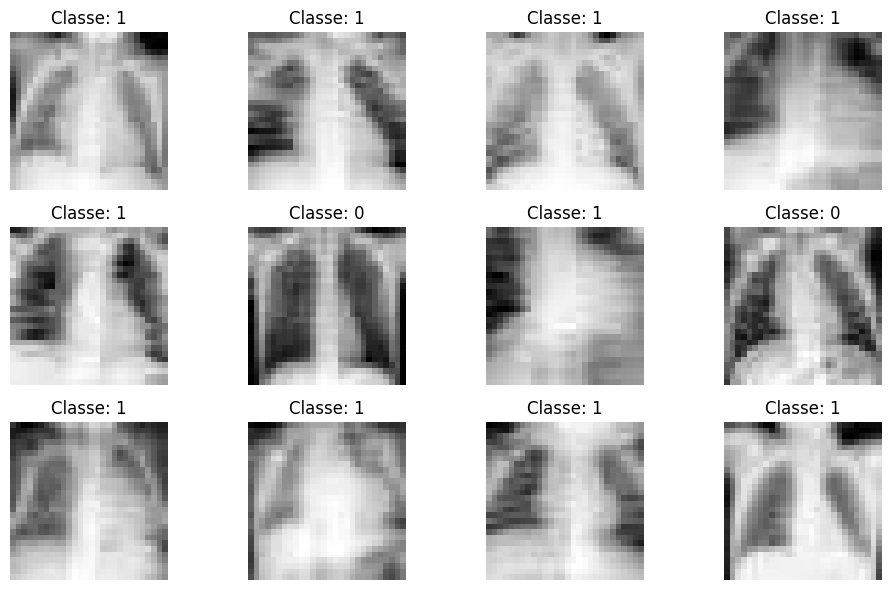

In [5]:
plt.figure(figsize=(10, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(train_dataset.imgs[i], cmap="gray")
    plt.title(f"Classe: {int(train_dataset.labels[i][0])}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("results/exemplos_dataset.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# 6. PREPARAÇÃO DAS IMAGENS

In [6]:
# MobileNetV2 espera imagens RGB.
# As imagens do PneumoniaMNIST são originalmente 28x28 em escala de cinza.
# Redimensionamos para 96x96 e replicamos o canal para obter RGB.

def prepare_images(images):
    images = images.astype("float32")
    images = np.expand_dims(images, axis=-1)
    images = np.repeat(images, 3, axis=-1)
    images = tf.image.resize(images, (IMG_SIZE, IMG_SIZE))
    images = preprocess_input(images)
    return images.numpy()

X_train = prepare_images(train_dataset.imgs)
X_val = prepare_images(val_dataset.imgs)
X_test = prepare_images(test_dataset.imgs)

y_train = train_dataset.labels.astype("float32").reshape(-1)
y_val = val_dataset.labels.astype("float32").reshape(-1)
y_test = test_dataset.labels.astype("float32").reshape(-1)

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

X_train: (4708, 96, 96, 3)
X_val: (524, 96, 96, 3)
X_test: (624, 96, 96, 3)


In [ ]:
# 7. DATA AUGMENTATION

In [7]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
], name="data_augmentation")

In [ ]:
# 8. CONSTRUÇÃO DO MODELO — TRANSFER LEARNING

In [8]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

# Primeira etapa: backbone congelado
base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.30)(x)
x = layers.Dense(64, activation="relu")(x)
x = layers.Dropout(0.20)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        81,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,340,033 (8.93 MB)

 Trainable params: 82,049 (320.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
# 9. CALLBACKS

In [9]:
checkpoint = callbacks.ModelCheckpoint(
    "models/mobilenetv2_pneumoniamnist_best.keras",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

In [ ]:
# 10. TREINAMENTO — ETAPA 1

In [10]:
history_head = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_HEAD,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

Epoch 1/10
147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8112 - auc: 0.8460 - loss: 0.4345
Epoch 1: val_accuracy improved from None to 0.89504, saving model to models/mobilenetv2_pneumoniamnist_best.keras

Epoch 1: finished saving model to models/mobilenetv2_pneumoniamnist_best.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 32s 185ms/step - accuracy: 0.8566 - auc: 0.9116 - loss: 0.3262 - val_accuracy: 0.8950 - val_auc: 0.9523 - val_loss: 0.2479 - learning_rate: 0.0010
Epoch 2/10
147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8912 - auc: 0.9527 - loss: 0.2466
Epoch 2: val_accuracy improved from 0.89504 to 0.91412, saving model to models/mobilenetv2_pneumoniamnist_best.keras

Epoch 2: finished saving model to models/mobilenetv2_pneumoniamnist_best.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 39s 172ms/step - accuracy: 0.8946 - auc: 0.9530 - loss: 0.2424 - val_accuracy: 0.9141 - val_auc: 0.9637 - val_loss: 0.2147 - learning_rate: 0.0010
Epoch 3/10
147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step

In [ ]:
# 11. FINE-TUNING

In [11]:
# Descongelamos apenas as últimas 30 camadas do MobileNetV2.
# As camadas iniciais permanecem congeladas para preservar
# características gerais aprendidas no ImageNet.

base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

# BatchNormalization permanece congelada para reduzir instabilidade
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(int(layer.trainable) for layer in base_model.layers)
print("Camadas treináveis do backbone:", trainable_count)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

history_fine = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS_FINE,
    batch_size=BATCH_SIZE,
    callbacks=[checkpoint, early_stop, reduce_lr],
    verbose=1
)

Camadas treináveis do backbone: 19
Epoch 1/10
147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.9246 - auc: 0.9689 - loss: 0.1945
Epoch 1: val_accuracy did not improve from 0.93321
148/148 ━━━━━━━━━━━━━━━━━━━━ 43s 252ms/step - accuracy: 0.9297 - auc: 0.9726 - loss: 0.1811 - val_accuracy: 0.9294 - val_auc: 0.9794 - val_loss: 0.1719 - learning_rate: 1.0000e-05
Epoch 2/10
147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.9338 - auc: 0.9775 - loss: 0.1686
Epoch 2: val_accuracy improved from 0.93321 to 0.93702, saving model to models/mobilenetv2_pneumoniamnist_best.keras

Epoch 2: finished saving model to models/mobilenetv2_pneumoniamnist_best.keras
148/148 ━━━━━━━━━━━━━━━━━━━━ 36s 241ms/step - accuracy: 0.9373 - auc: 0.9782 - loss: 0.1634 - val_accuracy: 0.9370 - val_auc: 0.9810 - val_loss: 0.1576 - learning_rate: 1.0000e-05
Epoch 3/10
147/148 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step - accuracy: 0.9407 - auc: 0.9819 - loss: 0.1472
Epoch 3: val_accuracy did not improve from 0.93702


In [ ]:
# 12. COMBINAÇÃO DOS HISTÓRICOS

In [12]:
acc = history_head.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history_head.history["val_accuracy"] + history_fine.history["val_accuracy"]

loss = history_head.history["loss"] + history_fine.history["loss"]
val_loss = history_head.history["val_loss"] + history_fine.history["val_loss"]

auc = history_head.history["auc"] + history_fine.history["auc"]
val_auc = history_head.history["val_auc"] + history_fine.history["val_auc"]

epochs_range = range(1, len(acc) + 1)
fine_start = len(history_head.history["accuracy"]) + 0.5

In [ ]:
# 13. CURVAS DE ACCURACY

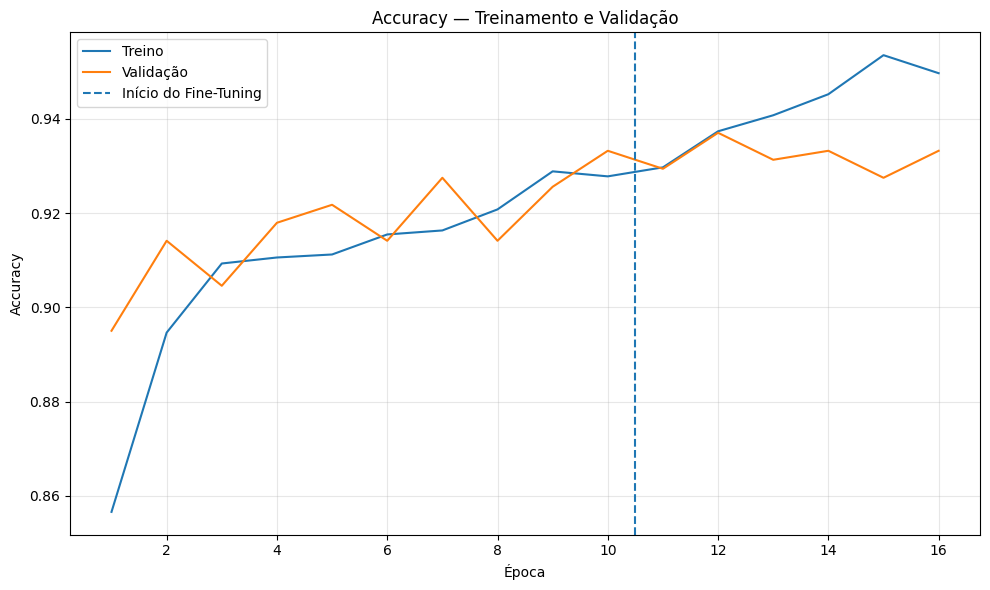

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, acc, label="Treino")
plt.plot(epochs_range, val_acc, label="Validação")
plt.axvline(fine_start, linestyle="--", label="Início do Fine-Tuning")
plt.title("Accuracy — Treinamento e Validação")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/curva_accuracy.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# 14. CURVAS DE LOSS

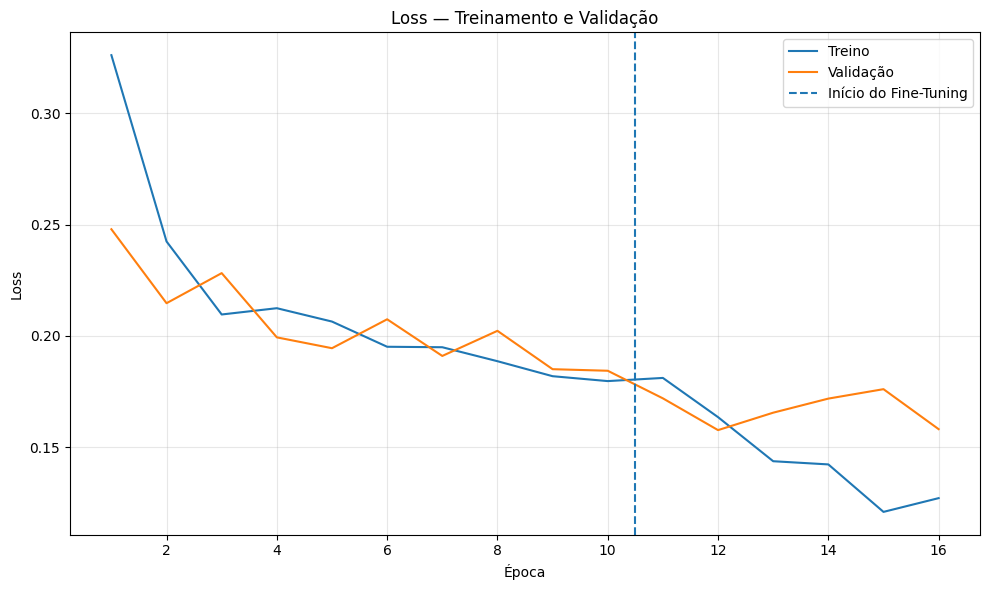

In [14]:
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, loss, label="Treino")
plt.plot(epochs_range, val_loss, label="Validação")
plt.axvline(fine_start, linestyle="--", label="Início do Fine-Tuning")
plt.title("Loss — Treinamento e Validação")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/curva_loss.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# 15. CURVA DE AUC

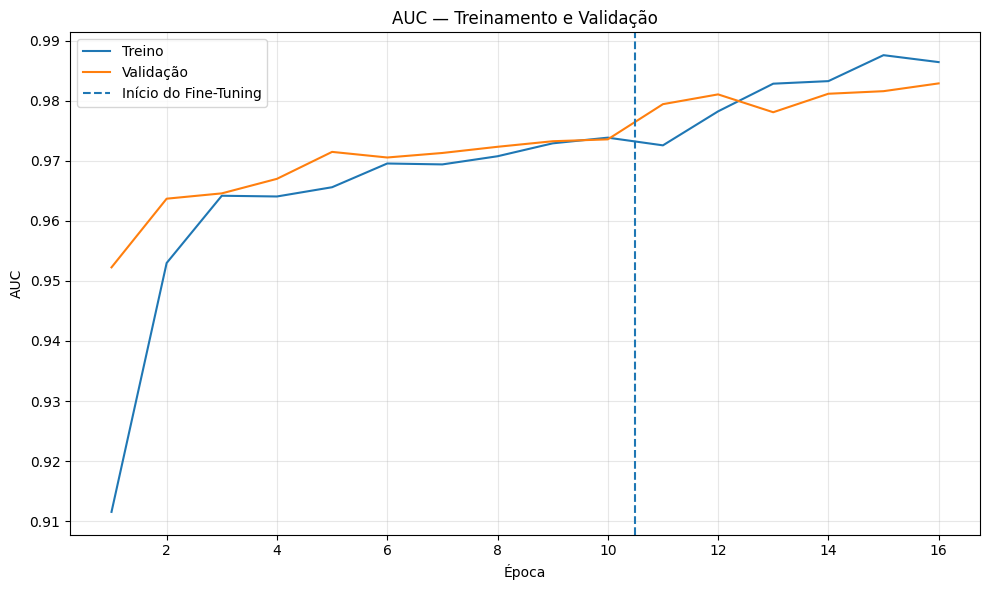

In [15]:
plt.figure(figsize=(10, 6))
plt.plot(epochs_range, auc, label="Treino")
plt.plot(epochs_range, val_auc, label="Validação")
plt.axvline(fine_start, linestyle="--", label="Início do Fine-Tuning")
plt.title("AUC — Treinamento e Validação")
plt.xlabel("Época")
plt.ylabel("AUC")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("results/curva_auc.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# 16. AVALIAÇÃO NO TESTE

In [16]:
best_model = tf.keras.models.load_model(
    "models/mobilenetv2_pneumoniamnist_best.keras"
)

test_results = best_model.evaluate(
    X_test, y_test,
    batch_size=BATCH_SIZE,
    verbose=1
)

print("\nResultados do teste:")
for name, value in zip(best_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 114ms/step - accuracy: 0.8606 - auc: 0.9475 - loss: 0.3756

Resultados do teste:
loss: 0.3756
compile_metrics: 0.8606


In [ ]:
# 17. PREVISÕES

In [17]:
probabilities = best_model.predict(X_test, batch_size=BATCH_SIZE)
predictions = (probabilities >= 0.5).astype(int).reshape(-1)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions,
        target_names=["Normal", "Pneumonia"],
        digits=4
    )
)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step

Classification Report:
              precision    recall  f1-score   support

      Normal     0.9455    0.6667    0.7820       234
   Pneumonia     0.8301    0.9769    0.8975       390

    accuracy                         0.8606       624
   macro avg     0.8878    0.8218    0.8397       624
weighted avg     0.8733    0.8606    0.8542       624



In [ ]:
# 18. MATRIZ DE CONFUSÃO

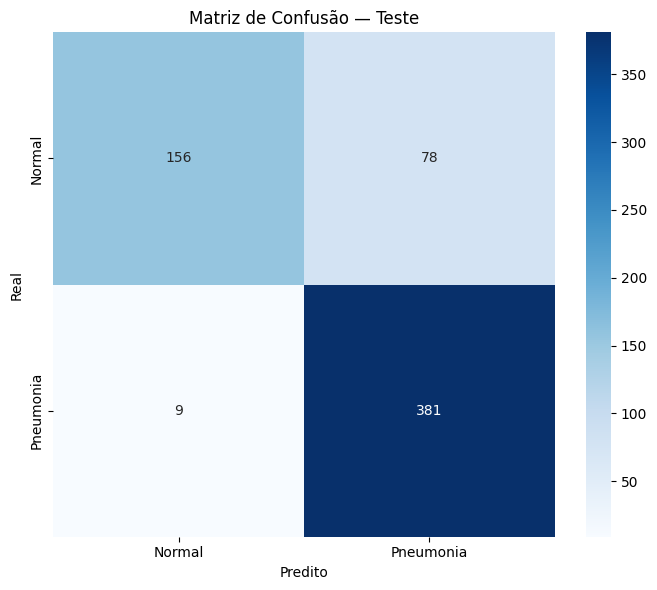

In [18]:
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Pneumonia"],
    yticklabels=["Normal", "Pneumonia"]
)
plt.title("Matriz de Confusão — Teste")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.savefig("results/matriz_confusao.png", dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
# 19. SALVAMENTO DO MODELO FINAL

In [19]:
best_model.save("models/pneumoniamnist_mobilenetv2_final.keras")

print("Modelo salvo em:")
print("models/pneumoniamnist_mobilenetv2_final.keras")

Modelo salvo em:
models/pneumoniamnist_mobilenetv2_final.keras


In [ ]:
# 20. RESUMO AUTOMÁTICO PARA O README

In [20]:
best_val_acc = max(val_acc)
best_val_loss = min(val_loss)
best_test_acc = test_results[1] if len(test_results) > 1 else None

print("\n================ RESUMO ================")
print(f"Melhor Validation Accuracy: {best_val_acc:.4f}")
print(f"Menor Validation Loss:      {best_val_loss:.4f}")
if best_test_acc is not None:
    print(f"Test Accuracy:              {best_test_acc:.4f}")
print("Backbone: MobileNetV2")
print("Pesos iniciais: ImageNet")
print("Fine-tuning: últimas 30 camadas treináveis do backbone")
print("=========================================")


================ RESUMO ================
Melhor Validation Accuracy: 0.9370
Menor Validation Loss:      0.1576
Test Accuracy:              0.8606
Backbone: MobileNetV2
Pesos iniciais: ImageNet
Fine-tuning: últimas 30 camadas treináveis do backbone
